# Valet Data Analysis

## Loading all the libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from adjustText import *
import pandas as pd
from plotnine import *
import scipy.stats as st
from scipy.interpolate import interp1d
from matplotlib.ticker import MaxNLocator
%matplotlib inline

# Game Set for Analysis

Each game to evaluate should be on a different line in "games".

In [2]:
fileprefix = "../CardStock/output/CardStockVM/"
games = [
    {"game":"Agram","name":"Agram", "player":3},
    {"game":"Blackjack","name":"Blackjack", "player":1},
    {"game":"CrazyEights","name":"Crazy Eights", "player":3},
    {"game":"Cribbage","name":"Cribbage", "player":2},
    {"game":"Cuckoo","name":"Cuckoo", "player":6},
    {"game":"Euchre","name":"Euchre", "player":4},
    {"game":"GoFish","name":"Go Fish", "player":4},
    {"game":"GolfSix","name":"Golf-6", "player":4},
    {"game":"GOPS","name":"Goofspiel", "player":2},
    {"game":"Hearts","name":"Hearts", "player": 4},
    {"game":"Klaverjassen","name":"Klaverjassen", "player":4},
    {"game":"LeducPoker","name":"Leudec Hold'em", "player":2},
    {"game":"Pitch","name":"Pitch", "player":4},
    {"game":"President","name":"President", "player":5},
    {"game":"BlockRummy","name":"Rummy", "player":2},
    {"game":"Scarto","name":"Scarto", "player":3},
    {"game":"Schwimmen","name":"Schwimmen", "player":5},
    {"game":"Scopa","name":"Scopa", "player":2},
    {"game":"Skittgube","name":"Skitgubbe", "player":3},
    {"game":"Sueca","name":"Sueca", "player":4},
    {"game":"Whist","name":"Whist", "player":4},    
]
gameframe = pd.DataFrame.from_dict(games)
gameframe["fileprefix"] = fileprefix
gameframe

,game,name,player,fileprefix
0,Agram,Agram,3,../CardStock/output/CardStockVM/
1,Blackjack,Blackjack,1,../CardStock/output/CardStockVM/
2,CrazyEights,Crazy Eights,3,../CardStock/output/CardStockVM/
3,Cribbage,Cribbage,2,../CardStock/output/CardStockVM/
4,Cuckoo,Cuckoo,6,../CardStock/output/CardStockVM/
5,Euchre,Euchre,4,../CardStock/output/CardStockVM/
6,GoFish,Go Fish,4,../CardStock/output/CardStockVM/
7,GolfSix,Golf-6,4,../CardStock/output/CardStockVM/
8,GOPS,Goofspiel,2,../CardStock/output/CardStockVM/
9,Hearts,Hearts,4,../CardStock/output/CardStockVM/


# Branching Factor

This first gathers data into a dataframe, which will enable us to draw graphs to show how the branching factor of the game changes over time.

This data is from games with all **random** players and games where the first player used a **MCTS** strategy.

In [3]:
first = True
for index, row in gameframe.iterrows():
    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "R" * row["player"] + "/choice.csv")
    print(row["game"])
    gf["game"] = row["game"]
    gf["name"] = row["name"]
    if first:
        choiceframe = gf
        first = False
    else:
        choiceframe = pd.concat([choiceframe, gf])
    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "M" + "R" * (row["player"] - 1) + "/choice.csv")
    gf["game"] = row["game"]
    gf["name"] = row["name"]
    choiceframe = pd.concat([choiceframe, gf])

Agram
Blackjack
CrazyEights
Cribbage
Cuckoo
Euchre
GoFish
GolfSix
GOPS
Hearts
Klaverjassen
LeducPoker
Pitch
President
BlockRummy
Scarto
Schwimmen
Scopa
Skittgube
Sueca
Whist


In [4]:
choiceframe.head()

,game,numPlayers,ai,imperfect,samples,tests,run,move,player,choices,choice,time,name
0,Agram,3,RRR,PRIVATE,10,1000,1,1,1,6,5,0,Agram
1,Agram,3,RRR,PRIVATE,10,1000,1,2,2,6,2,0,Agram
2,Agram,3,RRR,PRIVATE,10,1000,1,3,3,1,1,0,Agram
3,Agram,3,RRR,PRIVATE,10,1000,1,4,1,5,5,0,Agram
4,Agram,3,RRR,PRIVATE,10,1000,1,5,2,5,3,0,Agram


Individual games can be plotted.

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6 x 6 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ChoicesScarto.png


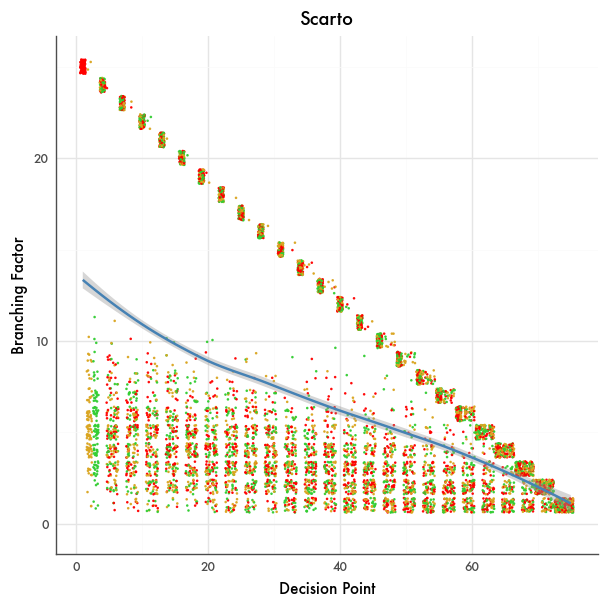

In [5]:
game = "Scarto"
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[(choiceframe["ai"].str.startswith("R")) & (choiceframe["game"] == game)], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.9)
 + geom_smooth(method="loess", color="steelblue")
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(6, 6))
 + theme(
        #plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='Decision Point', y='Branching Factor', title=gameframe[gameframe["game"]==game]["name"].item())
 + scale_colour_manual(values = ("red", "goldenrod", "limegreen", "cyan", "blue", "violet"))
)
cplot.save("Choices"+game+".png")
cplot.show()

## Plotting all games

This plot shows the branching factors over all of the games in the testbed for random players.

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: AllChoicesRandom.png


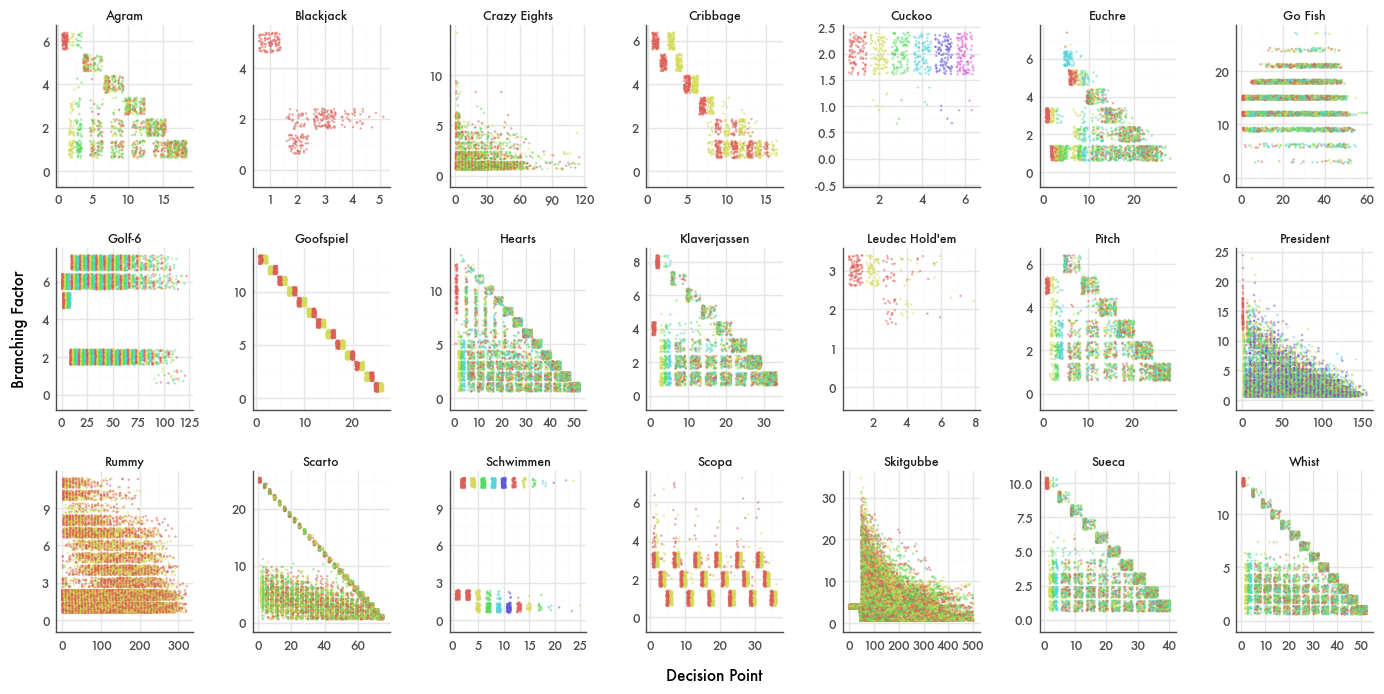

In [6]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[choiceframe["ai"].str.startswith("R")], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.4)
 + facet_wrap("name", scales = "free", ncol = 7)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(14, 7))
 + theme(
#        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        #axis_title=element_blank(),
        panel_spacing=0.02,
     
    )
 + labs(x='Decision Point', y='Branching Factor')

)
cplot.save("AllChoicesRandom.png")
cplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ChoicesMCTS.png


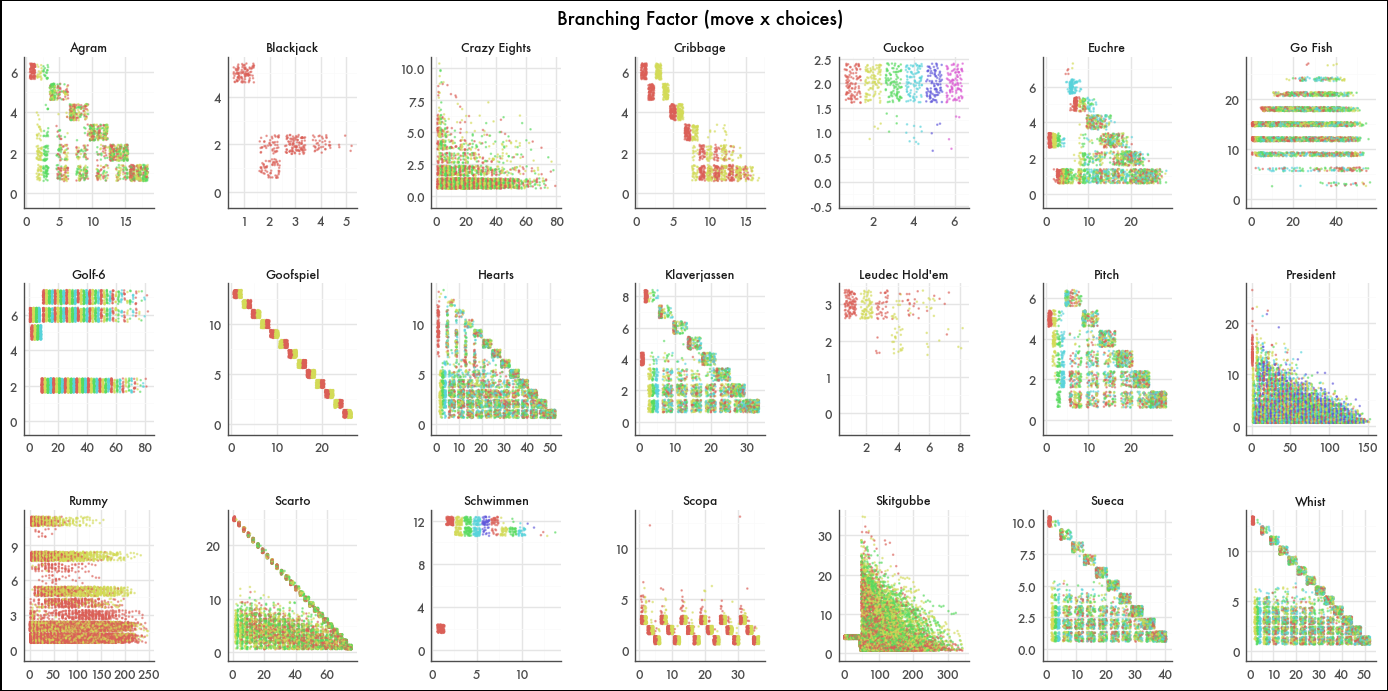

In [7]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[choiceframe["ai"].str.startswith("M")], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.5)
 + facet_wrap("name", scales = "free", ncol = 7)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(14, 7))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save("ChoicesMCTS.png")
cplot.show()

And one plot that shows them all.

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 20 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Choices.png


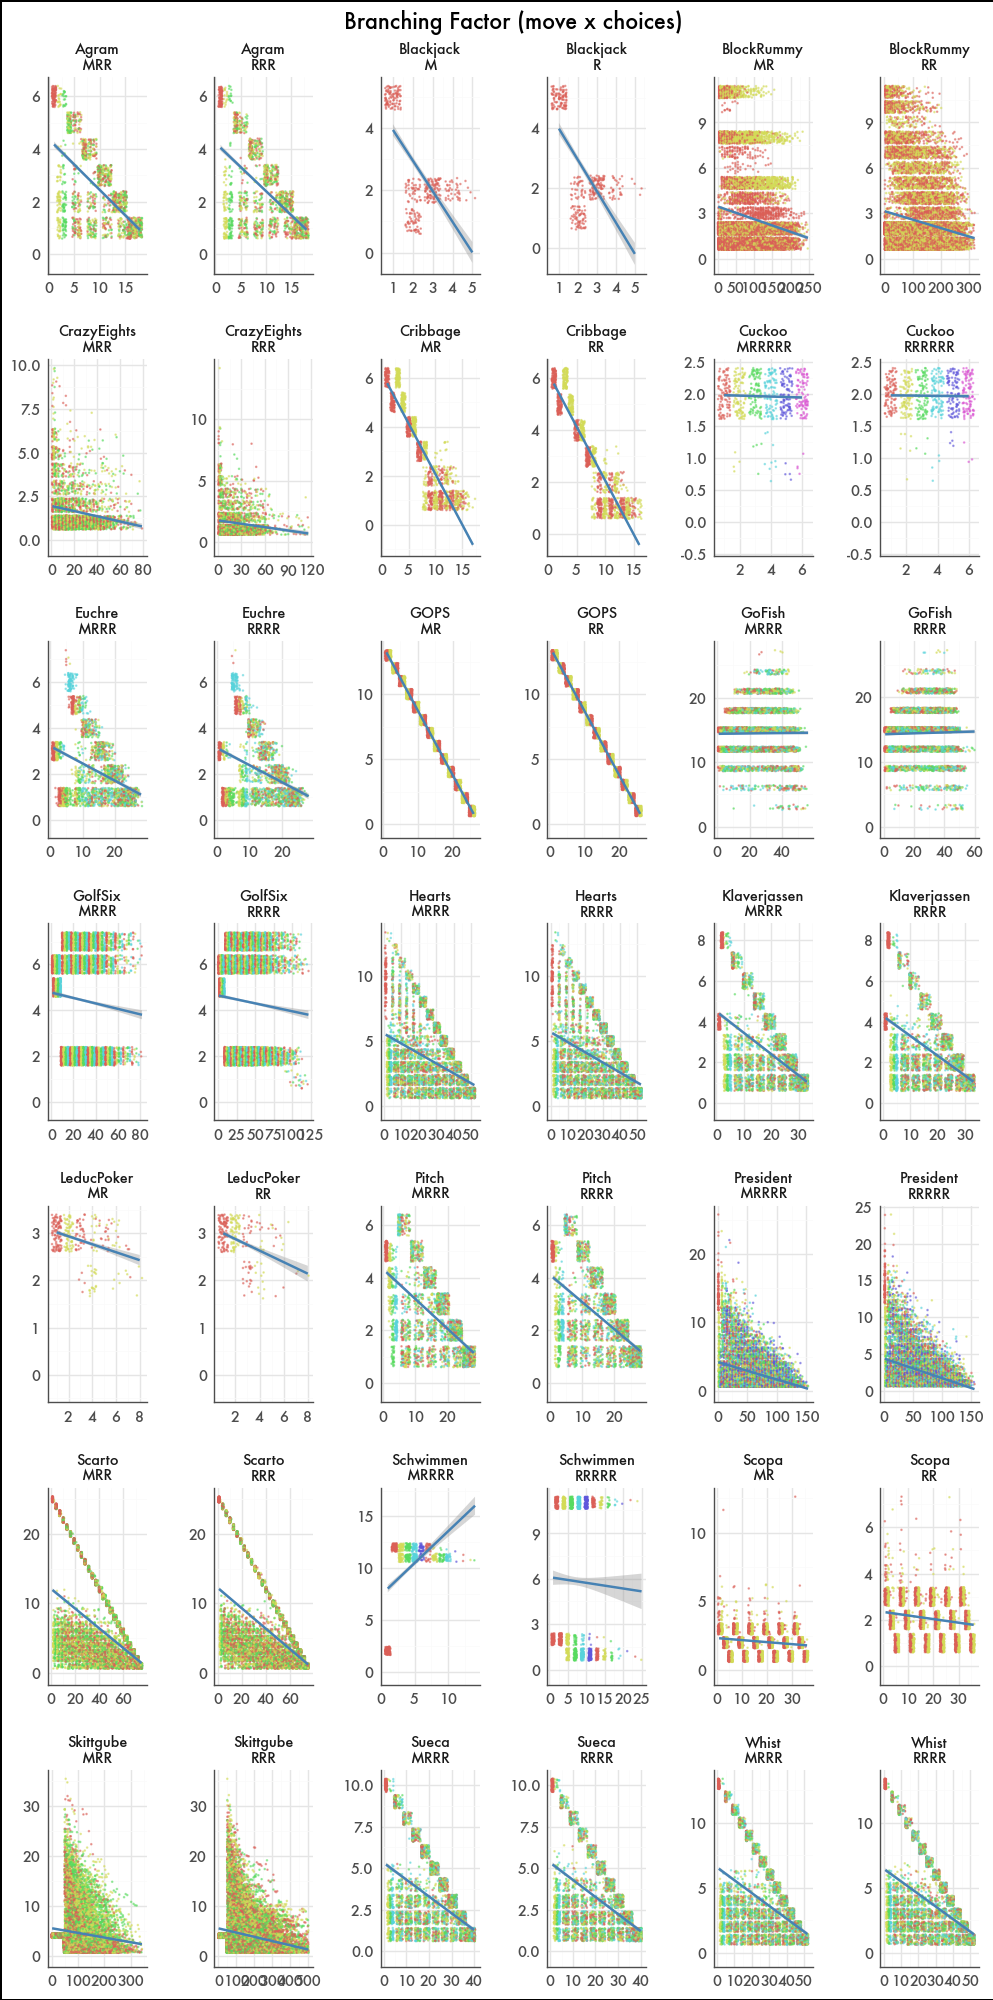

In [8]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe, aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.5)
 + geom_smooth(method="lm", color="steelblue")
 + facet_wrap(["game", "ai"], scales = "free", ncol = 6)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=13) 
 + theme(legend_position='none', figure_size=(10, 20))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save("Choices.png")
cplot.show()

# Game Length

We can calculate the average game length, by finding the max value for the move column on each run, then averaging

In [9]:
ai = "R"
lengthframe = choiceframe[['name', 'run', 'move']][choiceframe["ai"].str.startswith(ai)].groupby(['name', 'run'], as_index=False)['move'].max()
lengthframe.head()

,name,run,move
0,Agram,1,18
1,Agram,2,18
2,Agram,3,18
3,Agram,4,18
4,Agram,5,18


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 5 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: LengthCribbage.png


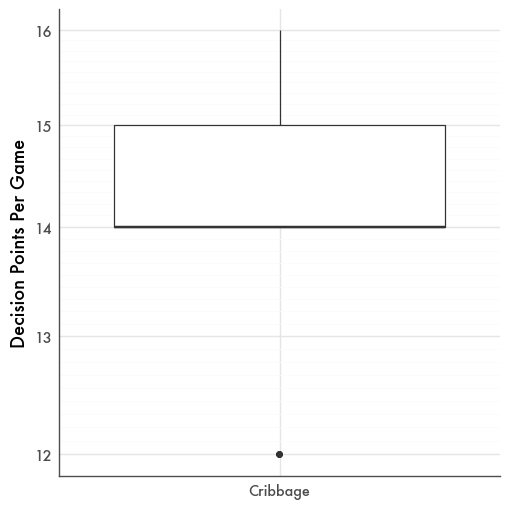

In [10]:
game = "Cribbage"
lplot = (ggplot(lengthframe[lengthframe["name"]==game], aes("name", "move"))
 + geom_boxplot()
 + theme_minimal(base_family="Futura", base_size=13) 
 + theme(legend_position='none', figure_size=(5, 5))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + scale_y_log10() 
 + labs(y="Decision Points Per Game", x="")
)
lplot.save("Length"+ game +".png")
lplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: LengthR.png


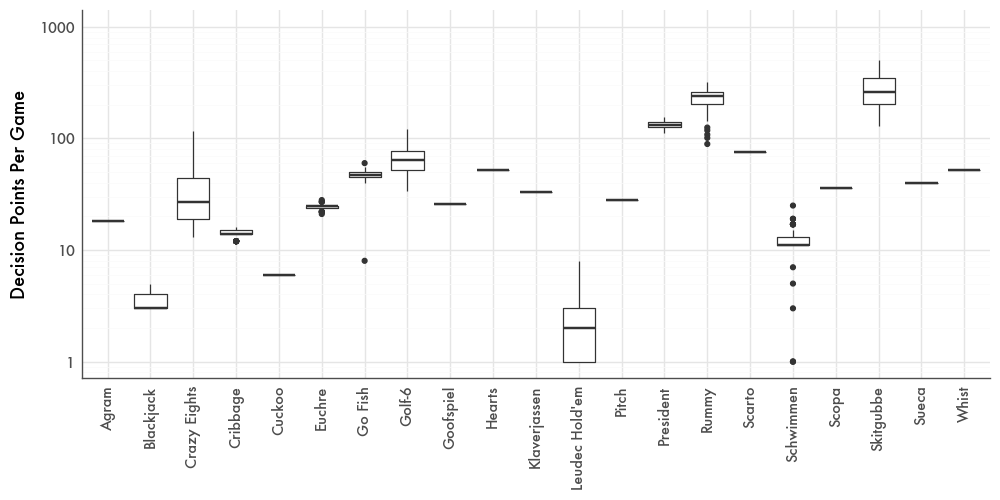

In [11]:
lplot = (ggplot(lengthframe, aes("name", "move"))
 + geom_boxplot()
 + theme_minimal(base_family="Futura", base_size=13) 
 + theme(legend_position='none', figure_size=(10, 5))
 + theme(
        axis_text_x=element_text(rotation=90),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + scale_y_log10(limits=(1, 1000))        
 + labs(y="Decision Points Per Game", x="")
)
lplot.save("Length" + ai + ".png")
lplot.show()

# Results

For random games, we want to look at the distribution of win/loss percentages across the players.

In [12]:
first = True
for index, row in gameframe.iterrows():
    print(row["game"])
    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "R" * row["player"] + "/results.csv")
    if row["game"] == "Schwimmen":
        gf["score"] = gf["score"] / 2.0
    gf["game"] = row["game"]
    gf["name"] = row["name"]
    gf["ai"] = "Random"
    if first:
        resultsframe = gf
        first = False
    else:
        resultsframe = pd.concat([resultsframe, gf])
    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "M" + "R" * (row["player"] - 1) + "/results.csv")
    if row["game"] == "Schwimmen":
        gf["score"] = gf["score"] / 2.0
    gf["game"] = row["game"]
    gf["name"] = row["name"]
    gf["ai"] = "MCTS"
    resultsframe = pd.concat([resultsframe, gf])

resultsframe["player"] = resultsframe["player"].astype(str)
resultsframe["rank"] = resultsframe["rank"].astype(str)
resultsframe

Agram
Blackjack
CrazyEights
Cribbage
Cuckoo
Euchre
GoFish
GolfSix
GOPS
Hearts
Klaverjassen
LeducPoker
Pitch
President
BlockRummy
Scarto
Schwimmen
Scopa
Skittgube
Sueca
Whist


,game,numPlayers,ai,imperfect,samples,tests,run,player,score,rank,time,name
0,Agram,3,Random,PRIVATE,10,1000,1,1,1.0,1,58.3252,Agram
1,Agram,3,Random,PRIVATE,10,1000,1,2,0.0,2,58.3252,Agram
2,Agram,3,Random,PRIVATE,10,1000,1,3,0.0,2,58.3252,Agram
3,Agram,3,Random,PRIVATE,10,1000,2,1,0.0,2,5.4835,Agram
4,Agram,3,Random,PRIVATE,10,1000,2,2,0.0,2,5.4835,Agram
...,...,...,...,...,...,...,...,...,...,...,...,...
395,Whist,4,MCTS,PRIVATE,10,1000,99,4,0.0,3,154479.9150,Whist
396,Whist,4,MCTS,PRIVATE,10,1000,100,1,2.0,1,164213.9285,Whist
397,Whist,4,MCTS,PRIVATE,10,1000,100,2,0.0,3,164213.9285,Whist
398,Whist,4,MCTS,PRIVATE,10,1000,100,3,2.0,1,164213.9285,Whist


# Timing

In [13]:
pgames = resultsframe[['name', 'run', 'ai', 'time']]
what = pgames.groupby(['name', 'run', 'ai'], as_index=False)['time'].max()
timef = what.groupby(['name', 'ai'], as_index=False).median()[['name', 'time', 'ai']]
timef

,name,time,ai
0,Agram,1.929883e+04,MCTS
1,Agram,3.461800e+00,Random
2,Blackjack,2.631346e+03,MCTS
3,Blackjack,1.716150e+00,Random
4,Crazy Eights,4.889077e+04,MCTS
5,Crazy Eights,3.596800e+00,Random
6,Cribbage,1.048595e+04,MCTS
7,Cribbage,8.218450e+00,Random
8,Cuckoo,2.390805e+03,MCTS
9,Cuckoo,2.121550e+00,Random


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Time.png


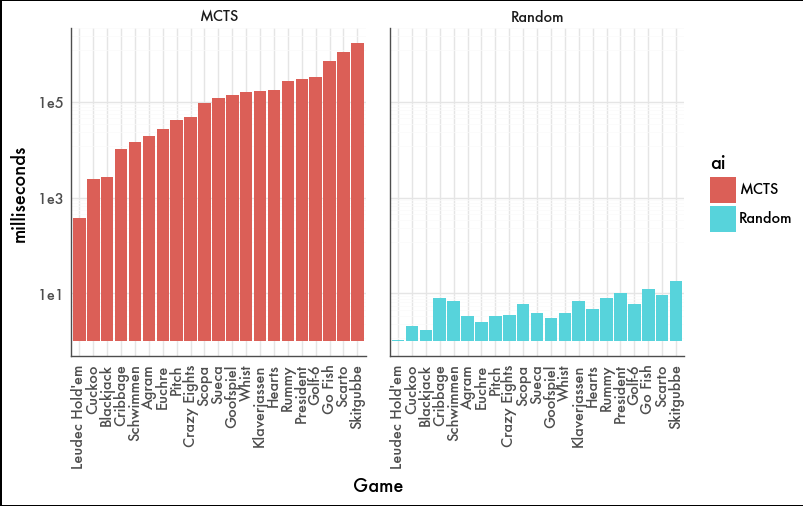

In [14]:
rplot = (ggplot(timef, aes("reorder(name, time)", "time", fill="ai"))
 + geom_bar(position="dodge", stat="identity")
 + facet_wrap(["ai"])
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(8, 5))
 + theme(
        axis_text_x=element_text(rotation=90),
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='Game', y='milliseconds')
 + scale_y_log10()
)
rplot.save("Time.png")
rplot.show()

In [15]:
rf2 = resultsframe.groupby(['name', 'player', 'rank', 'ai'], as_index=False).count()
rf3 = rf2[(rf2["player"]=="1") & (rf2["rank"] == "1")][["name", "ai", "run"]]
rf3["run"] = rf3["run"] / 100
rf4 = rf3.pivot(index='name', columns='ai')
rf4 = rf4["run"].reset_index()
rf4.columns.name=None
rf5 = rf4.merge(gameframe, on='name', how='left')
rf5

,name,MCTS,Random,game,player,fileprefix
0,Agram,0.59,0.33,Agram,3,../CardStock/output/CardStockVM/
1,Blackjack,1.00,1.00,Blackjack,1,../CardStock/output/CardStockVM/
2,Crazy Eights,0.48,0.40,CrazyEights,3,../CardStock/output/CardStockVM/
3,Cribbage,0.90,0.82,Cribbage,2,../CardStock/output/CardStockVM/
4,Cuckoo,0.88,0.79,Cuckoo,6,../CardStock/output/CardStockVM/
5,Euchre,0.61,0.42,Euchre,4,../CardStock/output/CardStockVM/
6,Go Fish,0.43,0.29,GoFish,4,../CardStock/output/CardStockVM/
7,Golf-6,0.85,0.29,GolfSix,4,../CardStock/output/CardStockVM/
8,Goofspiel,0.89,0.48,GOPS,2,../CardStock/output/CardStockVM/
9,Hearts,0.59,0.23,Hearts,4,../CardStock/output/CardStockVM/


In [16]:
def fairness(wp, np):
    if np == 1:
        return 1
    if wp < 1 / np:
        return wp * np
    else:
        return (np - np * wp) / (np - 1)
rf5["fairness"] = rf5.apply(lambda x: fairness(x.Random, x.player), axis=1)
def order(aiwp, np):
    if np == 1:
        return 1
    ewp = 1 / np
    return (aiwp - ewp) / (1 - ewp)
rf5["order"] = rf5.apply(lambda x: order(x.MCTS, x.player), axis=1)
rf5["gain"] = rf5.apply(lambda x: x.MCTS - x.Random, axis=1)
rf5

,name,MCTS,Random,game,player,fileprefix,fairness,order,gain
0,Agram,0.59,0.33,Agram,3,../CardStock/output/CardStockVM/,0.990000,0.385000,0.26
1,Blackjack,1.00,1.00,Blackjack,1,../CardStock/output/CardStockVM/,1.000000,1.000000,0.00
2,Crazy Eights,0.48,0.40,CrazyEights,3,../CardStock/output/CardStockVM/,0.900000,0.220000,0.08
3,Cribbage,0.90,0.82,Cribbage,2,../CardStock/output/CardStockVM/,0.360000,0.800000,0.08
4,Cuckoo,0.88,0.79,Cuckoo,6,../CardStock/output/CardStockVM/,0.252000,0.856000,0.09
5,Euchre,0.61,0.42,Euchre,4,../CardStock/output/CardStockVM/,0.773333,0.480000,0.19
6,Go Fish,0.43,0.29,GoFish,4,../CardStock/output/CardStockVM/,0.946667,0.240000,0.14
7,Golf-6,0.85,0.29,GolfSix,4,../CardStock/output/CardStockVM/,0.946667,0.800000,0.56
8,Goofspiel,0.89,0.48,GOPS,2,../CardStock/output/CardStockVM/,0.960000,0.780000,0.41
9,Hearts,0.59,0.23,Hearts,4,../CardStock/output/CardStockVM/,0.920000,0.453333,0.36


In [17]:
gameframe = gameframe.merge(rf5[["name", "fairness", "order", "gain", "MCTS"]], on="name", how="left")

In [18]:
gameframe

,game,name,player,fileprefix,fairness,order,gain,MCTS
0,Agram,Agram,3,../CardStock/output/CardStockVM/,0.990000,0.385000,0.26,0.59
1,Blackjack,Blackjack,1,../CardStock/output/CardStockVM/,1.000000,1.000000,0.00,1.00
2,CrazyEights,Crazy Eights,3,../CardStock/output/CardStockVM/,0.900000,0.220000,0.08,0.48
3,Cribbage,Cribbage,2,../CardStock/output/CardStockVM/,0.360000,0.800000,0.08,0.90
4,Cuckoo,Cuckoo,6,../CardStock/output/CardStockVM/,0.252000,0.856000,0.09,0.88
5,Euchre,Euchre,4,../CardStock/output/CardStockVM/,0.773333,0.480000,0.19,0.61
6,GoFish,Go Fish,4,../CardStock/output/CardStockVM/,0.946667,0.240000,0.14,0.43
7,GolfSix,Golf-6,4,../CardStock/output/CardStockVM/,0.946667,0.800000,0.56,0.85
8,GOPS,Goofspiel,2,../CardStock/output/CardStockVM/,0.960000,0.780000,0.41,0.89
9,Hearts,Hearts,4,../CardStock/output/CardStockVM/,0.920000,0.453333,0.36,0.59


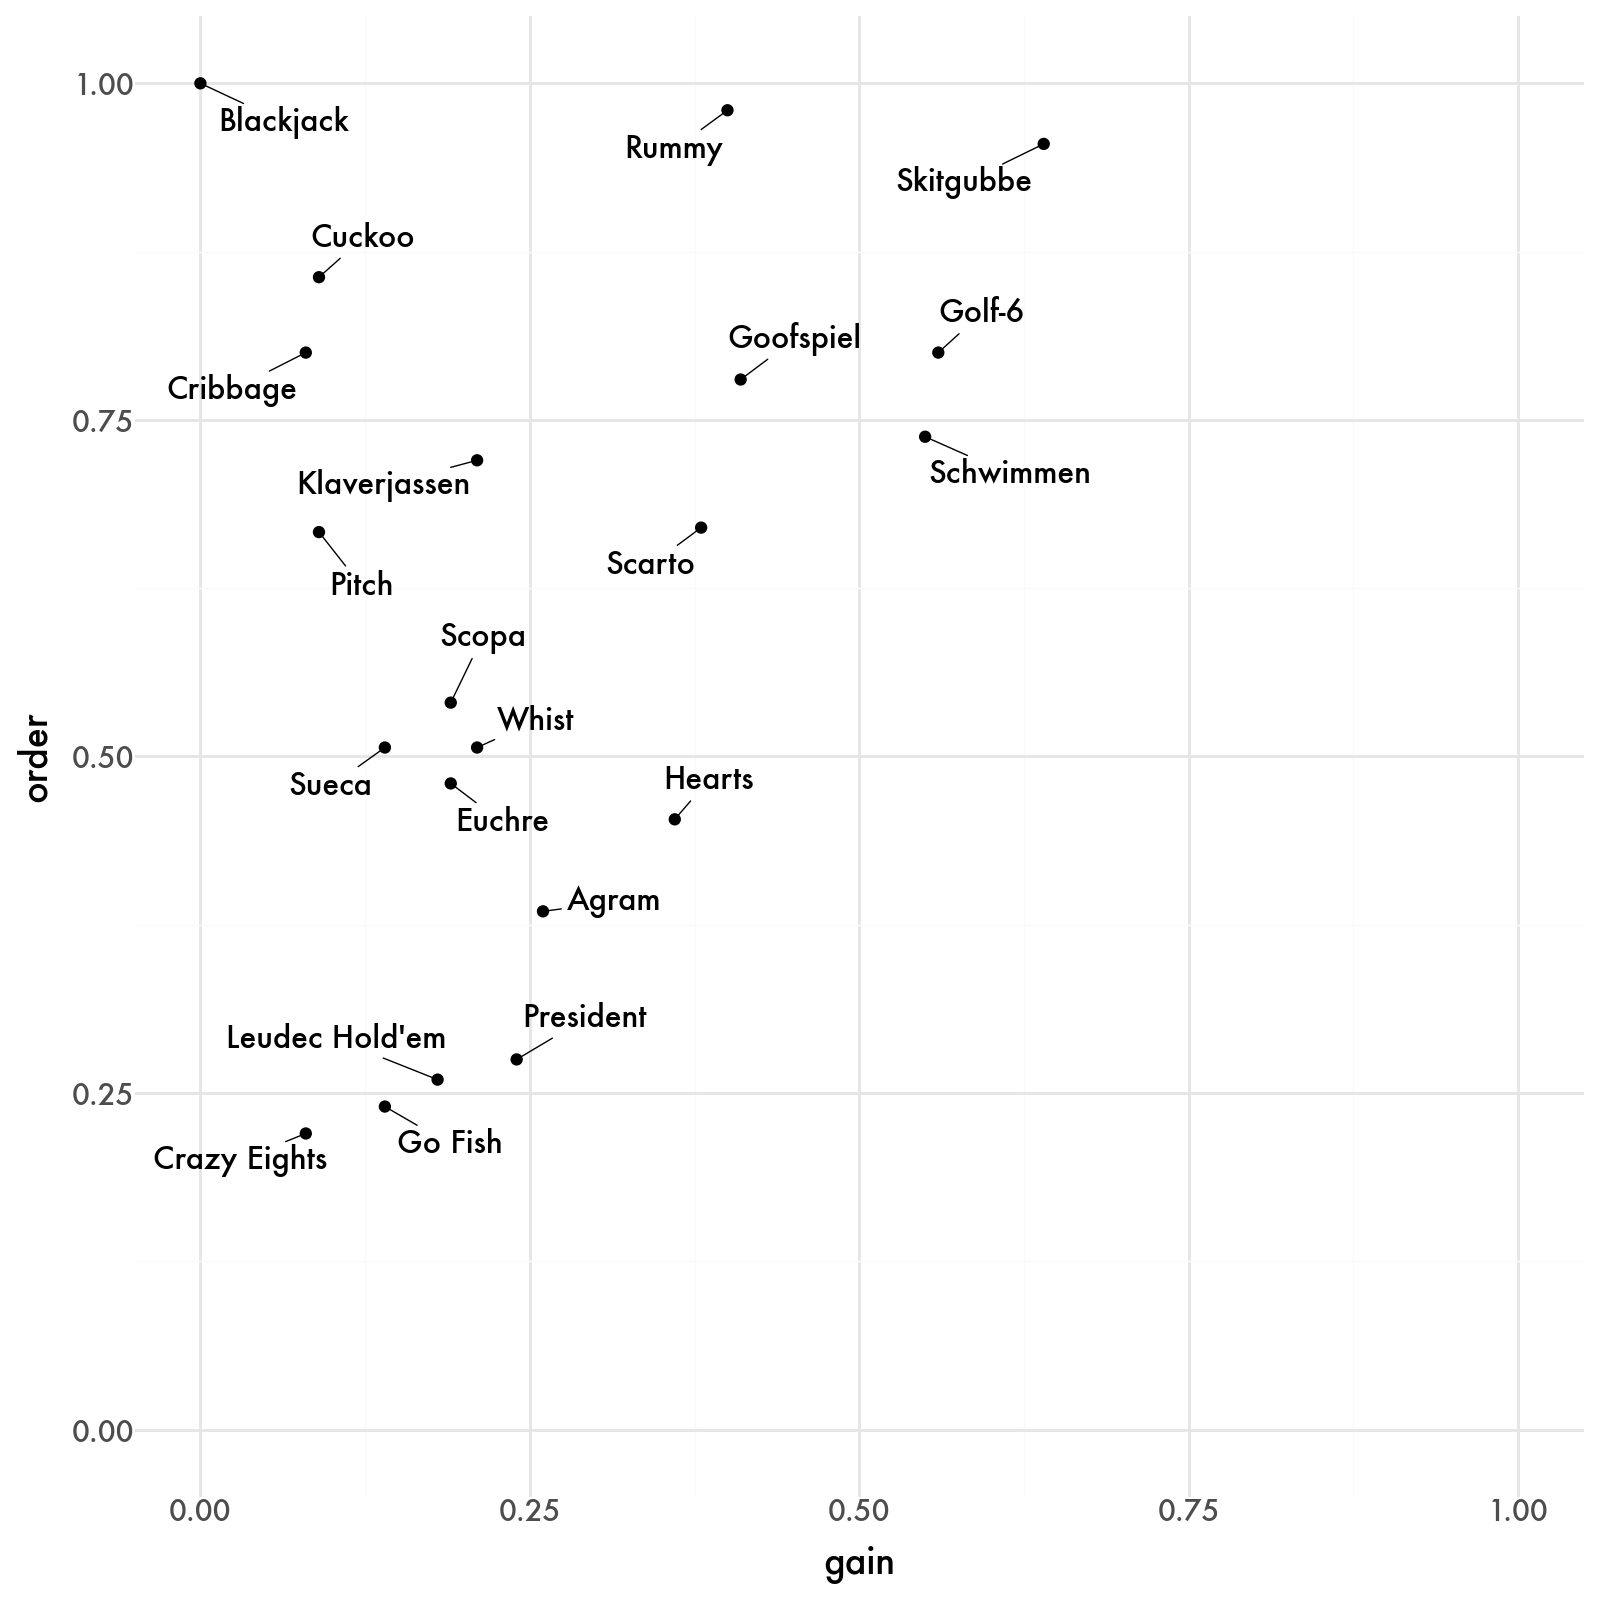

In [19]:
(ggplot(gameframe, aes("gain", "order", label="name"))
 + geom_point()
 + xlim(0, 1)
 + ylim(0, 1)
 + geom_text(adjust_text={"arrowprops": {"arrowstyle": "-"}})
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(8, 8))
)

In [20]:
rf6 = rf3.merge(gameframe[["game", "name", "gain", "player"]], on='name', how='left')
rf6.sort_values(by=['gain'])

,name,ai,run,game,gain,player
2,Blackjack,MCTS,1.00,Blackjack,0.00,1
3,Blackjack,Random,1.00,Blackjack,0.00,1
4,Crazy Eights,MCTS,0.48,CrazyEights,0.08,3
5,Crazy Eights,Random,0.40,CrazyEights,0.08,3
6,Cribbage,MCTS,0.90,Cribbage,0.08,2
7,Cribbage,Random,0.82,Cribbage,0.08,2
8,Cuckoo,MCTS,0.88,Cuckoo,0.09,6
9,Cuckoo,Random,0.79,Cuckoo,0.09,6
24,Pitch,MCTS,0.75,Pitch,0.09,4
25,Pitch,Random,0.66,Pitch,0.09,4


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Ranks.png


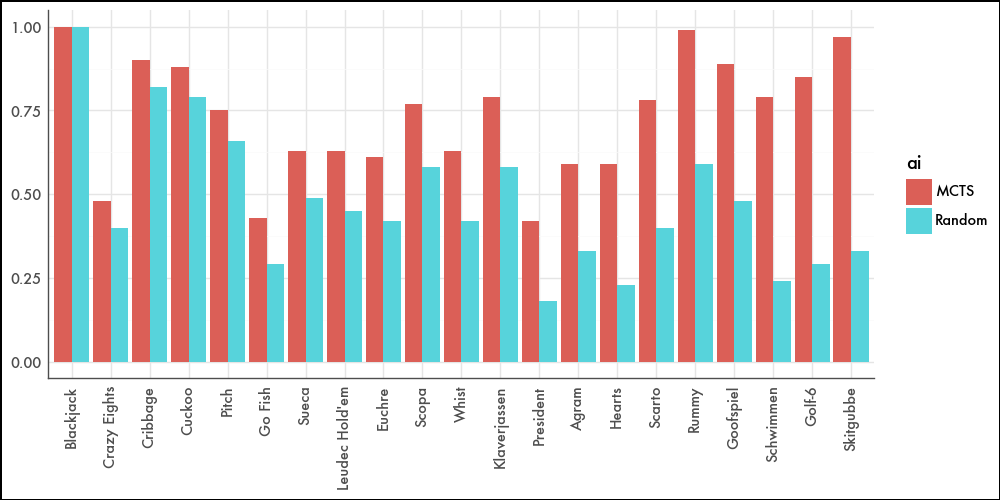

In [21]:
rplot = (ggplot(rf6, aes('reorder(name, gain)', "run", fill="ai"))
 + geom_bar(position="dodge", stat="identity")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(10, 5))
 + theme(
        axis_text_x=element_text(rotation=90),
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + ylim(0, 1)
 + labs(x='player', y='rank')
)
rplot.save("Ranks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 8 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: RandomScores.png


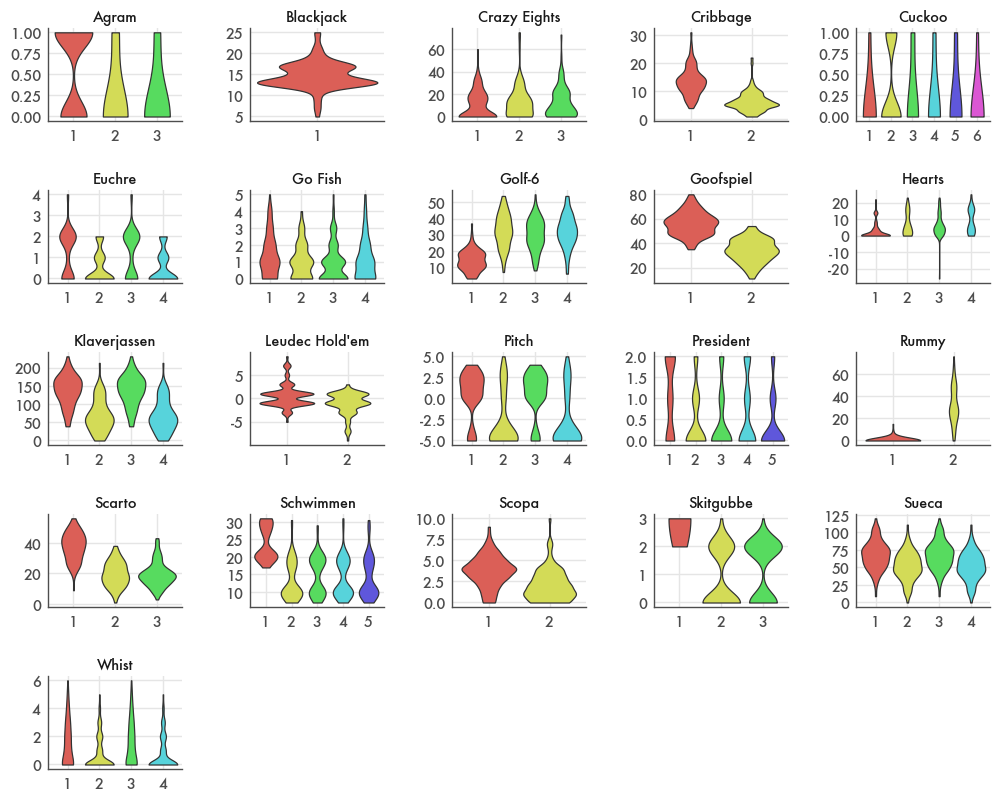

In [22]:
splot = (ggplot(resultsframe[resultsframe["ai"].str.startswith("M")], aes("player", "score", fill="player"))
 + geom_violin()
 + facet_wrap("name", scales = "free", ncol=5)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(10, 8))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='player', y='rank')
 + scale_y_continuous(minor_breaks=False)
)
splot.save("RandomScores.png")
splot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 12 x 6 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: RGolfSixScores.png


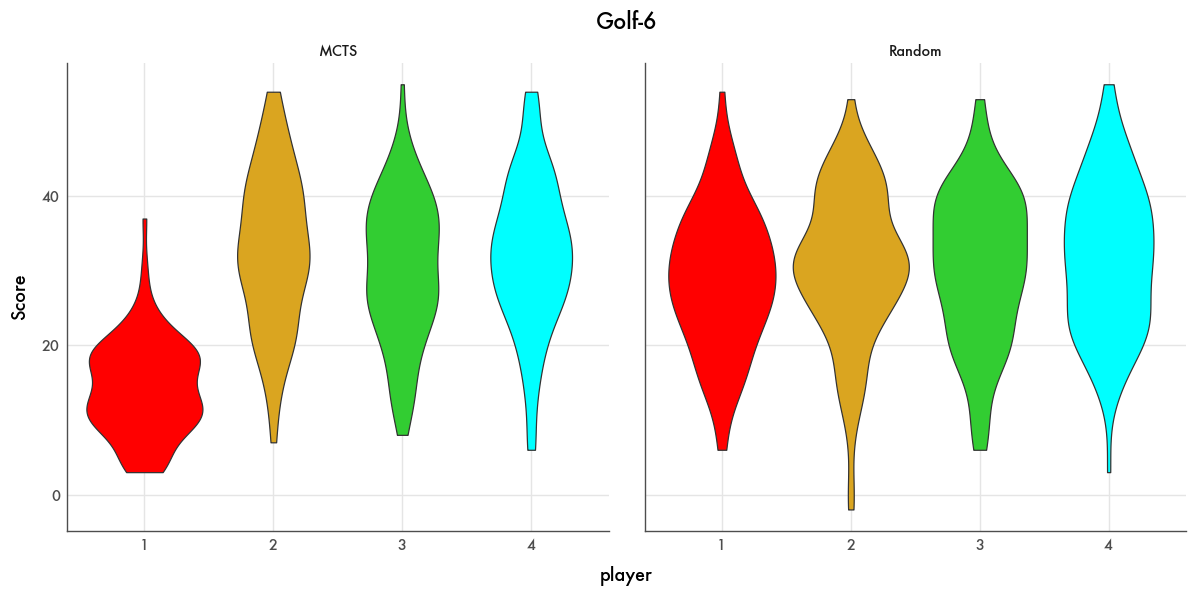

In [23]:
game = "GolfSix"
ai = "R"
splot = (ggplot(resultsframe[(resultsframe["game"] == game)], aes("player", "score", fill="player"))
 + geom_violin()
 + facet_wrap("ai")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(12, 6))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        #axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='player', y='Score', title=gameframe[gameframe["game"]==game]["name"].item())
 + scale_y_continuous(minor_breaks=False)
 + scale_fill_manual(values = ("red", "goldenrod", "limegreen", "cyan", "blue", "violet"))
)
splot.save(ai + game + "Scores.png")
splot.show()

In [24]:
resultsframe[(resultsframe["ai"].str.startswith(ai)) & (resultsframe["game"] == game)& (resultsframe["player"] == "2")]["score"]

1      43.0
5      29.0
9      46.0
13     34.0
17     17.0
       ... 
381    30.0
385    12.0
389    30.0
393    24.0
397    28.0
Name: score, Length: 100, dtype: float64

In [25]:
resultsframe

,game,numPlayers,ai,imperfect,samples,tests,run,player,score,rank,time,name
0,Agram,3,Random,PRIVATE,10,1000,1,1,1.0,1,58.3252,Agram
1,Agram,3,Random,PRIVATE,10,1000,1,2,0.0,2,58.3252,Agram
2,Agram,3,Random,PRIVATE,10,1000,1,3,0.0,2,58.3252,Agram
3,Agram,3,Random,PRIVATE,10,1000,2,1,0.0,2,5.4835,Agram
4,Agram,3,Random,PRIVATE,10,1000,2,2,0.0,2,5.4835,Agram
...,...,...,...,...,...,...,...,...,...,...,...,...
395,Whist,4,MCTS,PRIVATE,10,1000,99,4,0.0,3,154479.9150,Whist
396,Whist,4,MCTS,PRIVATE,10,1000,100,1,2.0,1,164213.9285,Whist
397,Whist,4,MCTS,PRIVATE,10,1000,100,2,0.0,3,164213.9285,Whist
398,Whist,4,MCTS,PRIVATE,10,1000,100,3,2.0,1,164213.9285,Whist


In [26]:
rf2 = resultsframe[resultsframe["ai"].str.startswith("M")].groupby(['game', 'player', 'rank'], as_index=False).count()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 14 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: AIRanks.png


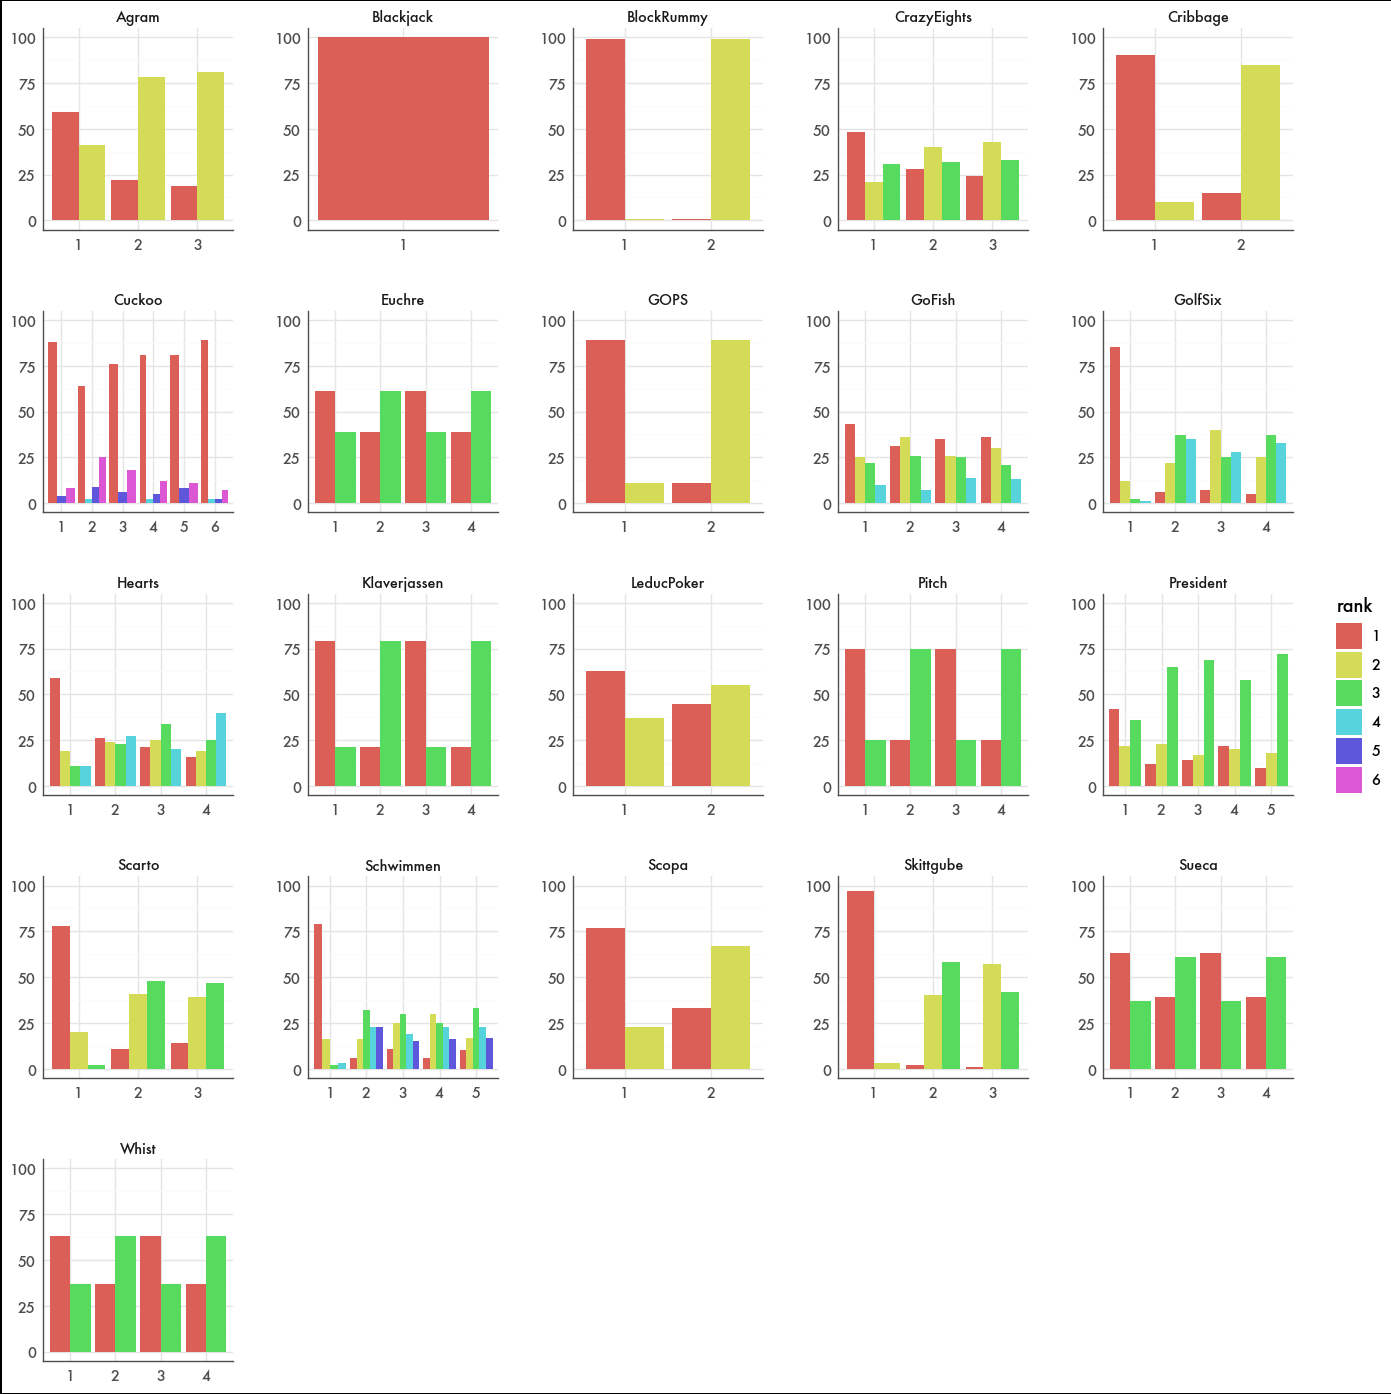

In [27]:
rplot = (ggplot(rf2, aes("player", "run", fill="rank"))
 + geom_bar(position="dodge", stat="identity")
 + facet_wrap("game", scales = "free", ncol=5)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(14, 14))
 + ylim(0, 100)
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='player', y='rank')
)
rplot.save("AIRanks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 8 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: PvsRScores.png


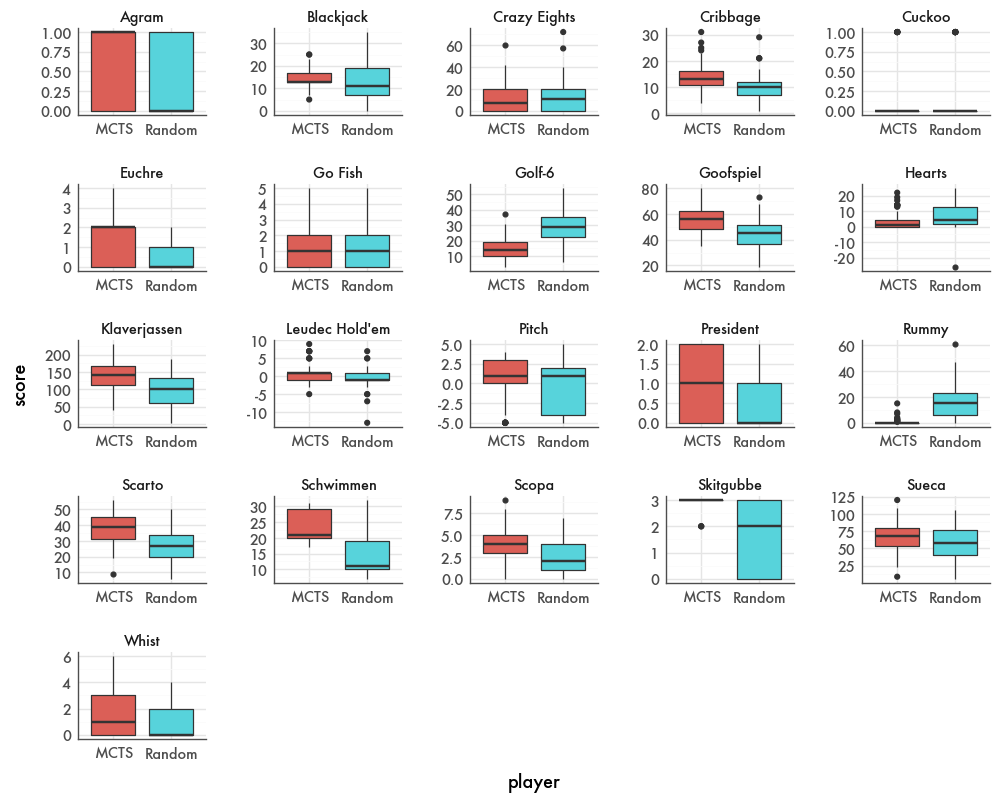

In [28]:
resultsframe["rank"] = resultsframe["rank"].astype(int)

splot = (ggplot(resultsframe[resultsframe["player"]=="1"], aes("ai", "score", fill="ai"))
 + geom_boxplot()
 + facet_wrap("name", scales = "free", ncol=5)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(10, 8))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='player', y='score')
)
splot.save("PvsRScores.png")
splot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 6 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: MvsRScores.png


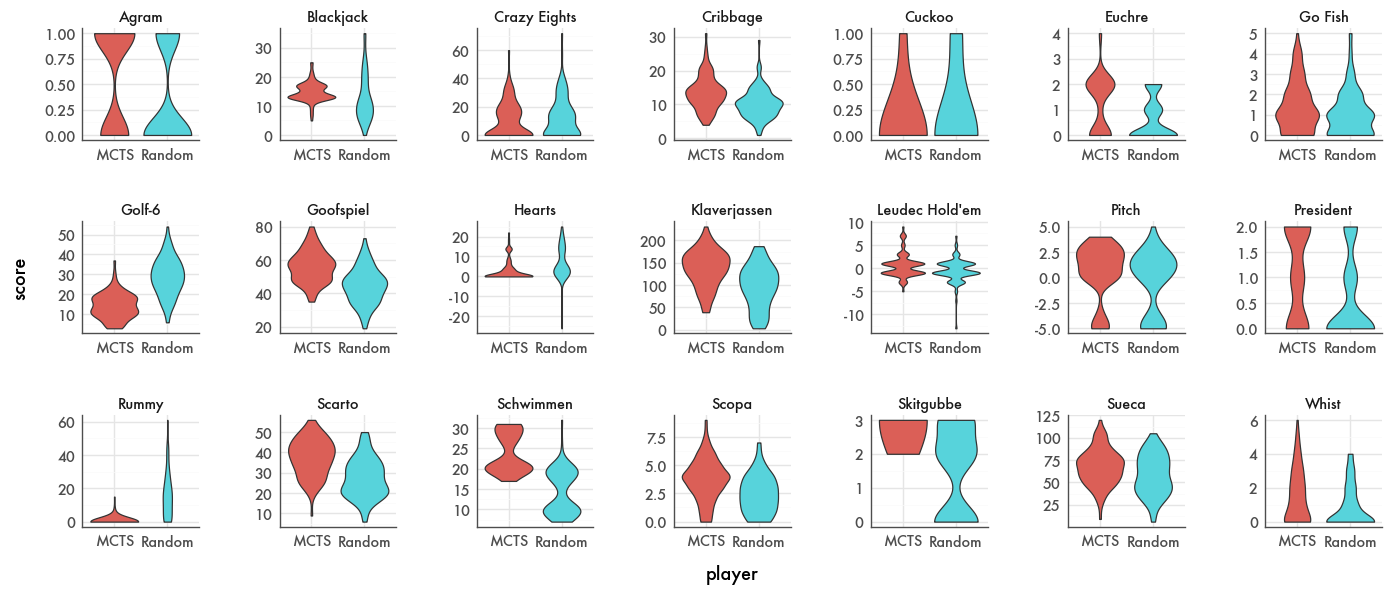

In [29]:
resultsframe["rank"] = resultsframe["rank"].astype(int)

splot = (ggplot(resultsframe[resultsframe["player"]=="1"], aes("ai", "score", fill="ai"))
 + geom_violin()
 + facet_wrap("name", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 6))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='player', y='score')
)
splot.save("MvsRScores.png")
splot.show()

In [30]:
def sig_code(pval):
    if pval < 0.001:
        return "***"
    elif pval < 0.01:
        return "**"
    elif pval < 0.05:
        return "*"
    elif pval < 0.1:
        return "."
    else:
        return ""
comp = resultsframe[resultsframe["player"]=="1"][["game", "ai", "run", "score"]]
comp = comp.pivot(index=["game", "run"], columns="ai", values="score")
comp2 = comp.groupby("game").apply(lambda df: st.ttest_ind(df['MCTS'], df['Random'])[1]).reset_index().rename(columns={0:"p-value"})[["game", "p-value"]]
comp3 = comp.groupby('game').apply(lambda df: sig_code(st.ttest_ind(df['MCTS'], df['Random'])[1])).reset_index().rename(columns={0:"significance"})
comp4 = comp3.merge(comp2, on="game", how="left").sort_values(by="p-value")
comp4

,game,significance,p-value
16,Schwimmen,***,1.201839e-29
9,GolfSix,***,1.586912e-27
2,BlockRummy,***,5.087641e-24
18,Skittgube,***,4.631452e-23
7,GOPS,***,1.038922e-13
15,Scarto,***,1.335103e-12
11,Klaverjassen,***,1.883948e-09
17,Scopa,***,1.159340e-06
4,Cribbage,***,2.077165e-06
6,Euchre,***,6.986509e-06
